# 04. Baseline Model Tuning (Logistic Regression)

## Purpose
Establish a strong **Baseline** performance using Logistic Regression.
Any advanced model (like XGBoost) *must* beat this score to be worth the complexity.

## Steps
1.  **Load Engineered Data**: Use the Scaled/Encoded data from Step 03.
2.  **Training**: Train a Logistic Regression model.
3.  **Hyperparameter Tuning**: Test different Regularization strengths (Value of `C`) to find the best fit.
4.  **Threshold Tuning**: Find the optimal probability cutoff to maximize F1 Score (Balance of Precision/Recall).


In [1]:
import pandas as pd
from pathlib import Path
import numpy as np

# Load the engineered dataset
ROOT = Path.cwd().parent
DATA_PATH = ROOT / "data" / "processed" / "insurance_claims_engineered_final.csv"
# Fallback if running from different dir
if not DATA_PATH.exists():
    DATA_PATH = Path("../data/processed/insurance_claims_engineered_final.csv")

if DATA_PATH.exists():
    df_fe = pd.read_csv(DATA_PATH)
    print(f"✅ Loaded df_fe from {DATA_PATH}")
    print("Shape:", df_fe.shape)
else:
    print(f"❌ File not found: {DATA_PATH}")


✅ Loaded df_fe from /Users/tatiana/Desktop/ML Projects/SEP25-BDS-Claim-Prediction/data/processed/insurance_claims_engineered_final.csv
Shape: (1000, 59)


In [2]:
# ============================================================
# step_20 CONSOLIDATE FINAL ENGINEERED DATA → PREP FOR MODELING
# ============================================================
# Why:
# - Move from feature engineering → modeling.
# - Ensure df_model has ONLY final engineered features.
# - Remove all raw or redundant columns.
# - Build X/y cleanly.
# - Perform stratified train/test split.
# - Rebuild explicit binary/categorical/numeric groups from TRAIN.

import numpy as np
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# 1) DROP RAW & DEPRECATED COLUMNS
# ------------------------------------------------------------
deprecated_cols = [
    "total_claim_amount",          # replaced by claim_amount_risk_band_encoded
    "policy_annual_premium",       # replaced by is_high_risk_premium
    "months_as_customer",          # replaced by customer_tenure_bucket
    "days_since_bind",             # replaced by days_since_bind_bucket_final
    "claim_amount_risk_band",      # replaced by encoded version
    "claim_decile",                # explicitly removed
    "auto_make",
    "auto_model",
    "policy_annual_premium_bin",
    "days_since_bind_bin",
    "incident_severity",           # replaced by incident_severity_is_major
]

df_model = df_fe.drop(
    columns=[c for c in deprecated_cols if c in df_fe.columns]
).copy()

print("🔥 df_model shape:", df_model.shape)

# ------------------------------------------------------------
# 2) BUILD X / y
# ------------------------------------------------------------
assert "target" in df_model.columns
X = df_model.drop(columns=["target"])
y = df_model["target"]

print("X:", X.shape, "| y:", y.shape)

# ------------------------------------------------------------
# 3) STRATIFIED TRAIN/TEST SPLIT
# ------------------------------------------------------------
SEED = 42

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

print("Train:", X_tr.shape, "| Test:", X_te.shape)
print("Fraud rate → train:", y_tr.mean().round(3), "| test:", y_te.mean().round(3))

# ------------------------------------------------------------
# 4) AUTO-DETECT COLUMN TYPES (FROM TRAIN ONLY — no leakage)
# ------------------------------------------------------------
num_auto = X_tr.select_dtypes(include=[np.number]).columns.tolist()
cat_auto = X_tr.select_dtypes(include=["object", "category"]).columns.tolist()

# ------------------------------------------------------------
# 5) EXPLICIT MANUAL BINARY ENGINEERED FEATURES (0/1 flags)
# ------------------------------------------------------------
binary_features = [
    "collision_type_missing",
    "property_damage_missing",
    "police_report_available_missing",
    "authorities_contacted_missing",
    "incident_weekend",
    "is_holiday",
    "holiday_window_2d",
    "is_high_risk_premium",
    "incident_severity_is_major",
    "fraud_time_window_flag",
]

# ------------------------------------------------------------
# 6) FINAL FEATURE GROUPING
# ------------------------------------------------------------
numeric_features = [c for c in num_auto if c not in binary_features]

categorical_features = [
    c for c in cat_auto
    if c not in binary_features
]

print("Binary:", len(binary_features))
print("Categorical:", len(categorical_features))
print("Numeric:", len(numeric_features))



🔥 df_model shape: (1000, 49)
X: (1000, 48) | y: (1000,)
Train: (800, 48) | Test: (200, 48)
Fraud rate → train: 0.248 | test: 0.245
Binary: 10
Categorical: 19
Numeric: 21


In [3]:
# ============================================================
# step_21 PREPROCESSOR — FINAL VERSION (StandardScaler restored)
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("bin", "passthrough", binary_features),   # engineered 0/1 flags
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

print("Preprocessor ready (StandardScaler)!")


Preprocessor ready (StandardScaler)!


In [4]:
# ============================================================
# step_22 BASELINE MODELS — LINEAR ONLY (LogReg / Ridge / LDA / NB)
# ============================================================
# Why:
# - Tree models belong in a separate notebook with raw continous features.
# - This notebook focuses on the linear family only.
# - These models benefit from StandardScaler + engineered buckets.
# - Cleaner baselines, faster CV, more interpretable coefficients.

from sklearn.linear_model import LogisticRegression, RidgeClassifierCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB

from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score


# -------------------------
# Logistic Regression
# -------------------------
pipe_logreg = Pipeline([
    ("pre", preprocessor),
    ("clf", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",   # helps with fraud class imbalance
        solver="lbfgs"
    )),
])


# -------------------------
# Ridge Classifier
# -------------------------
pipe_ridge = Pipeline([
    ("pre", preprocessor),
    ("clf", RidgeClassifierCV())   # internal CV picks best alpha
])


# -------------------------
# Linear Discriminant Analysis
# -------------------------
pipe_lda = Pipeline([
    ("pre", preprocessor),
    ("clf", LinearDiscriminantAnalysis())
])


# -------------------------
# Naive Bayes
# -------------------------
# Included as a weak baseline — often finds hidden interactions
pipe_nb = Pipeline([
    ("pre", preprocessor),
    ("clf", GaussianNB())
])


# -------------------------
# Dictionary for iteration
# -------------------------
models = {
    "LogReg":  pipe_logreg,
    "RidgeCV": pipe_ridge,
    "LDA":     pipe_lda,
    "NB":      pipe_nb,
}

print("🔥 Linear baseline model pipelines ready!")


🔥 Linear baseline model pipelines ready!


In [5]:
# ============================================================
# step_23 BASELINE EVALUATION — ACCURACY / AUC / CLASS REPORT
# ============================================================

results = {}

for name, model in models.items():
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None

    auc = roc_auc_score(y_te, y_proba) if y_proba is not None else None

    results[name] = {
        "AUC": auc,
        "Accuracy": model.score(X_te, y_te),
        "Report": classification_report(y_te, y_pred, output_dict=True)
    }

    print("\n============================================================")
    print(f" {name} — baseline results")
    print("============================================================")
    print("Accuracy:", results[name]["Accuracy"])
    print("AUC:", results[name]["AUC"])
    print(classification_report(y_te, y_pred))


ValueError: A given column is not a column of the dataframe

In [ ]:
# ============================================================
# step_25 HYPERPARAMETER TUNING — LOGREG (LBFGS, L2)
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logreg_param = {
    "clf__C": np.logspace(-1, 1, 10)   # 0.1 → 10
}

logreg_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs",       # <-- consistent with baseline
        penalty="l2"
    )),
])

logreg_search = RandomizedSearchCV(
    estimator=logreg_pipe,
    param_distributions=logreg_param,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    random_state=SEED,
)

logreg_search.fit(X_tr, y_tr)

print("LogReg tuned AUC:", logreg_search.best_score_)
tuned_models["LogReg"] = logreg_search.best_estimator_


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning:

The total space of parameters 10 is smaller than n_iter=20. Running 10 iterations. For exhaustive searches, use GridSearchCV.



LogReg tuned AUC: 0.7462050487391395


In [ ]:
# ============================================================
# step_25 HYPERPARAMETER TUNING — LOGISTIC REGRESSION (L2 + LBFGS)
# ============================================================
# Why:
# - Stay consistent with the baseline model (lbfgs + L2).
# - Only tune the regularization strength C.
# - Keep class_weight="balanced" because fraud = minority class.
# - Avoid adding solvers or penalties that downgrade performance.
# - QuantileTransformer removed → baseline uses StandardScaler again.

from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# ------------------------------------------------------------
# Parameter space (logscale: 0.1 → 10)
# ------------------------------------------------------------
logreg_param = {
    "clf__C": np.logspace(-1, 1, 10)  # [0.1, ..., 10]
}

# ------------------------------------------------------------
# Pipeline (exactly baseline structure)
# ------------------------------------------------------------
logreg_pipe = Pipeline([
    ("pre", preprocessor),   # StandardScaler + OHE + passthrough flags
    ("clf", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs",      # ← same as baseline
        penalty="l2"         # ← only valid with lbfgs
    )),
])

# ------------------------------------------------------------
# RandomizedSearchCV (but space = 10 → runs 10 iterations)
# ------------------------------------------------------------
logreg_search = RandomizedSearchCV(
    estimator=logreg_pipe,
    param_distributions=logreg_param,
    n_iter=10,               # coherent with search space size
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    random_state=SEED,
)

# ------------------------------------------------------------
# Fit & store best model
# ------------------------------------------------------------
logreg_search.fit(X_tr, y_tr)
tuned_models["LogReg"] = logreg_search.best_estimator_

print("LogReg tuned AUC:", logreg_search.best_score_)
print("Best C:", logreg_search.best_params_["clf__C"])


LogReg tuned AUC: 0.7462050487391395
Best C: 0.1


In [ ]:
y_proba_tuned = tuned_models["LogReg"].predict_proba(X_te)[:, 1]
test_auc_tuned = roc_auc_score(y_te, y_proba_tuned)
print("Tuned LogReg TEST AUC:", test_auc_tuned)


Tuned LogReg TEST AUC: 0.8202459791863765


🔥 Best threshold (F1-max): 0.587
Precision at best: 0.66
Recall at best: 0.673
F1 at best: 0.667


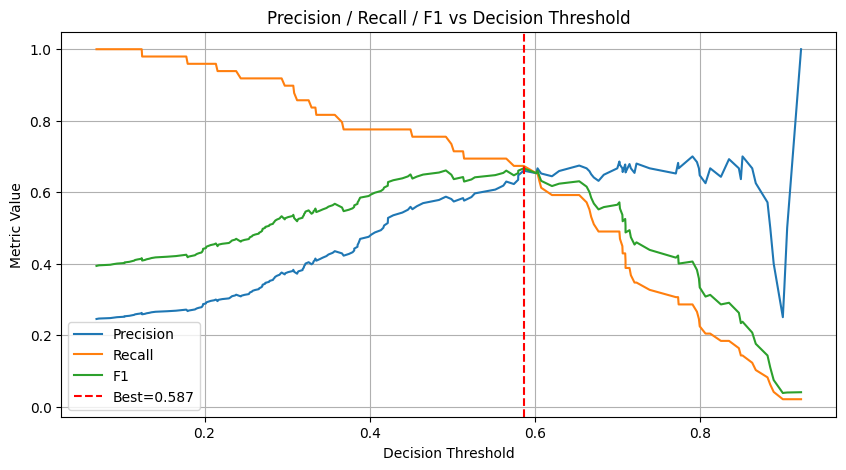


Confusion Matrix @ best threshold:
[[134  17]
 [ 16  33]]

Classification Report @ best threshold:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       151
           1       0.66      0.67      0.67        49

    accuracy                           0.83       200
   macro avg       0.78      0.78      0.78       200
weighted avg       0.84      0.83      0.84       200



In [ ]:
# ============================================================
# step_26 DECISION THRESHOLD TUNING — PRECISION / RECALL / F1
# ============================================================
# Why:
# - LogisticRegression default threshold = 0.50 is rarely optimal for fraud.
# - AUC tells ranking quality, but threshold sets *behavior*.
# - We choose threshold based on precision/recall/F1 balance.
# - Goal: catch more fraud (↑ recall) without drowning in false positives.

from sklearn.metrics import precision_recall_curve, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Compute prediction probabilities (using tuned model)
# ------------------------------------------------------------
y_proba = tuned_models["LogReg"].predict_proba(X_te)[:, 1]

# ------------------------------------------------------------
# 2) Precision–Recall curve across all possible thresholds
# ------------------------------------------------------------
precisions, recalls, thresholds = precision_recall_curve(y_te, y_proba)

# F1 for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

# ------------------------------------------------------------
# 3) Find the threshold that maximizes F1
# ------------------------------------------------------------
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("🔥 Best threshold (F1-max):", round(best_threshold, 3))
print("Precision at best:", round(precisions[best_idx], 3))
print("Recall at best:", round(recalls[best_idx], 3))
print("F1 at best:", round(f1_scores[best_idx], 3))

# ------------------------------------------------------------
# 4) Plot metrics vs threshold
# ------------------------------------------------------------
plt.figure(figsize=(10,5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.plot(thresholds, f1_scores[:-1], label="F1")
plt.axvline(best_threshold, color="red", linestyle="--", label=f"Best={best_threshold:.3f}")
plt.xlabel("Decision Threshold")
plt.ylabel("Metric Value")
plt.title("Precision / Recall / F1 vs Decision Threshold")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 5) Final confusion matrix at best threshold
# ------------------------------------------------------------
y_pred_thresh = (y_proba >= best_threshold).astype(int)
cm = confusion_matrix(y_te, y_pred_thresh)
print("\nConfusion Matrix @ best threshold:")
print(cm)

# Optional: full classification report
from sklearn.metrics import classification_report
print("\nClassification Report @ best threshold:")
print(classification_report(y_te, y_pred_thresh))


In [ ]:
# ============================================================
# step_27 SAVE TUNED LOGREG + PREPROCESSOR + THRESHOLD
# ============================================================

import joblib
from pathlib import Path

ARTIFACTS = Path("../models")
ARTIFACTS.mkdir(exist_ok=True)

BEST_MODEL = tuned_models["LogReg"]
BEST_THRESHOLD = 0.587   # replace with your computed best_threshold variable

# Save the entire pipeline (preprocessor + tuned model)
joblib.dump(BEST_MODEL, ARTIFACTS / "logreg_tuned_pipeline.joblib")

# Save threshold
with open(ARTIFACTS / "logreg_best_threshold.txt", "w") as f:
    f.write(str(BEST_THRESHOLD))

print("✅ Saved:")
print("- logreg_tuned_pipeline.joblib")
print("- logreg_best_threshold.txt")
print("Threshold:", BEST_THRESHOLD)


✅ Saved:
- logreg_tuned_pipeline.joblib
- logreg_best_threshold.txt
Threshold: 0.587
